In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

CSV = '/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/clustered-interactions_pt2/F15_KMAX3_DMAX4_NMIN1500--/youngser-pca-feature-rank.csv'

df = pd.read_csv(CSV).sort_values('pca_importance_pct', ascending=False).reset_index(drop=True)

# clean labels + split into feature / track
def split_feature(f):
    if f.startswith('track1_'):
        return f.replace('track1_', ''), 'Track 1'
    if f.startswith('track2_'):
        return f.replace('track2_', ''), 'Track 2'
    return f, 'Both'

df[['feature', 'track']] = df['base_feature'].apply(lambda f: pd.Series(split_feature(f)))
df['feature'] = df['feature'].str.replace('_', ' ').str.replace('t1 head-head t2', 'head–head distance')

def category(f):
    if 'distance' in f: return 'Distance'
    if 'approach' in f: return 'Approach angle'
    if 'speed' in f: return 'Speed'
    if 'acceleration' in f: return 'Acceleration'
    return 'Angle'
df['category'] = df['feature'].apply(category)

cat_colours = {'Distance': '#4C72B0', 'Approach angle': '#DD8452', 'Speed': '#55A868',
               'Angle': '#C44E52', 'Acceleration': '#8172B3'}
df

,base_feature,pca_importance,pca_importance_pct,feature,track,category
0,t1_head-head_t2,0.240130,24.013020,head–head distance,Both,Distance
1,track1_approach_angle,0.213211,21.321062,approach angle,Track 1,Approach angle
2,track2_approach_angle,0.199613,19.961338,approach angle,Track 2,Approach angle
3,track2_speed_tail,0.095634,9.563439,speed tail,Track 2,Speed
4,track1_speed_tail,0.067377,6.737676,speed tail,Track 1,Speed
5,track1_speed_head,0.062012,6.201198,speed head,Track 1,Speed
6,track2_speed_head,0.056689,5.668855,speed head,Track 2,Speed
7,track2_angle,0.022624,2.262387,angle,Track 2,Angle
8,track1_angle,0.019100,1.910027,angle,Track 1,Angle
9,track2_acceleration_body,0.005391,0.539122,acceleration body,Track 2,Acceleration


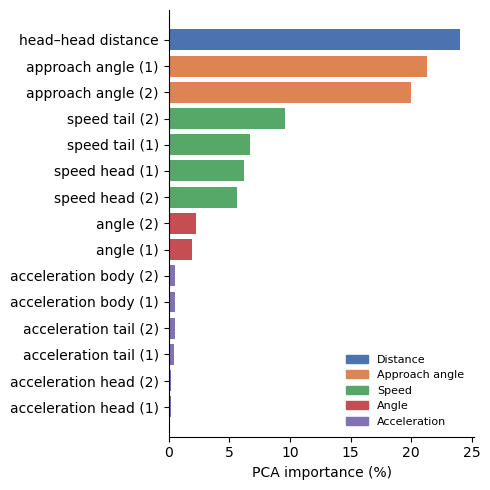

In [10]:
# OPTION 1: ranked horizontal bars, coloured by feature category
label = df['feature'] + np.where(df['track'] == 'Both', '', ' (' + df['track'].str[-1] + ')')

fig, ax = plt.subplots(figsize=(5, 5))
ax.barh(label[::-1], df['pca_importance_pct'][::-1], color=df['category'][::-1].map(cat_colours))
ax.set_xlabel('PCA importance (%)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=col, label=c) for c, col in cat_colours.items()], frameon=False, fontsize=8, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

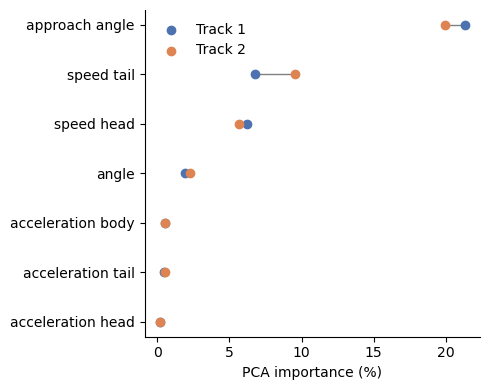

In [11]:
# OPTION 2: track 1 vs track 2 side by side (shows the two larvae contribute equally)
paired = df[df['track'] != 'Both'].pivot_table(index='feature', columns='track', values='pca_importance_pct')
paired = paired.loc[paired.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(5, 4))
y = np.arange(len(paired))
ax.hlines(y, paired.min(axis=1), paired.max(axis=1), color='grey', lw=1)
ax.scatter(paired['Track 1'], y, color='#4C72B0', label='Track 1', zorder=3)
ax.scatter(paired['Track 2'], y, color='#DD8452', label='Track 2', zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(paired.index)
ax.set_xlabel('PCA importance (%)')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

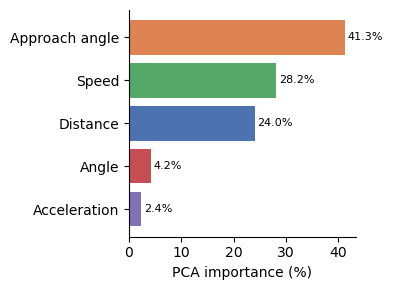

In [12]:
# OPTION 3: summed by category (track 1 + track 2 combined) - simplest story
by_cat = df.groupby('category')['pca_importance_pct'].sum().sort_values()

fig, ax = plt.subplots(figsize=(4, 3))
ax.barh(by_cat.index, by_cat.values, color=by_cat.index.map(cat_colours))
for i, v in enumerate(by_cat.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlabel('PCA importance (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

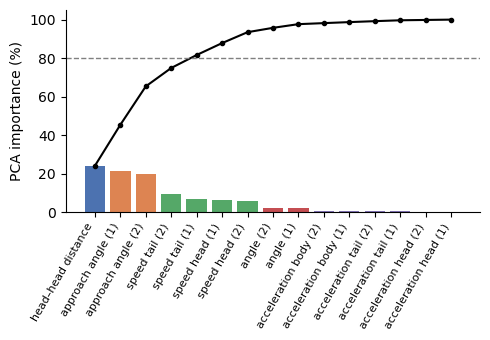

In [13]:
# OPTION 4: cumulative importance (how many features explain most of the PC)
cum = df['pca_importance_pct'].cumsum()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(range(len(df)), df['pca_importance_pct'], color=df['category'].map(cat_colours))
ax.plot(range(len(df)), cum, color='black', marker='o', ms=3)
ax.axhline(80, color='grey', ls='--', lw=1)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(label, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('PCA importance (%)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

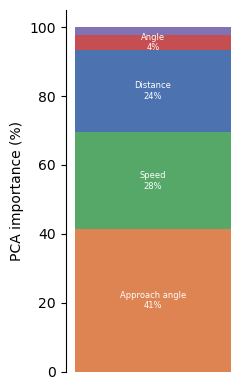

In [14]:
# OPTION 5: single stacked bar (compact, fits beside a PCA plot)
fig, ax = plt.subplots(figsize=(2.6, 4))
bottom = 0
for c, v in by_cat.sort_values(ascending=False).items():
    ax.bar(0, v, bottom=bottom, color=cat_colours[c], width=0.9)
    if v > 3:
        ax.text(0, bottom + v / 2, f'{c}\n{v:.0f}%', ha='center', va='center', fontsize=6, color='white')
    bottom += v
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel('PCA importance (%)')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout()
plt.show()

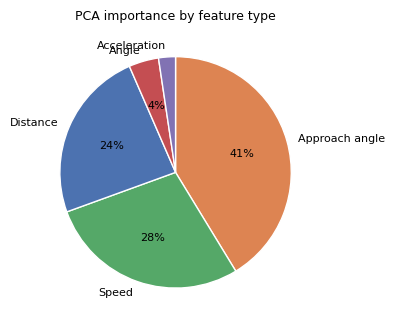

In [15]:
# OPTION 6: pie chart by category
order = by_cat.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(order.values, labels=order.index, colors=order.index.map(cat_colours),
       autopct=lambda p: f'{p:.0f}%' if p > 3 else '', startangle=90, counterclock=False,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1}, textprops={'fontsize': 8})
ax.set_title('PCA importance by feature type', fontsize=9)
plt.tight_layout()
plt.show()

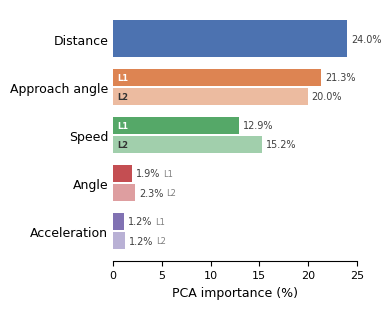

In [19]:
# OPTION 7: summed by category, larva 1 and larva 2 as separate bars
from matplotlib.colors import to_rgba

by_cat_track = df.groupby(['category', 'track'])['pca_importance_pct'].sum()
order = df.groupby('category')['pca_importance_pct'].max().sort_values().index  # largest single bar at top

fig, ax = plt.subplots(figsize=(4, 3.2))
bar_h = 0.36
gap = 0.04

for i, c in enumerate(order):
    col = cat_colours[c]
    tracks = by_cat_track[c]
    if 'Both' in tracks:
        bars = [(i, tracks['Both'], 2 * bar_h + gap, '', col)]
    else:
        bars = [(i + (bar_h + gap) / 2, tracks['Track 1'], bar_h, 'L1', col),
                (i - (bar_h + gap) / 2, tracks['Track 2'], bar_h, 'L2', to_rgba(col, 0.55))]
    for y, v, h, name, fc in bars:
        ax.barh(y, v, height=h, color=fc, edgecolor='none')
        ax.text(v + 0.4, y, f'{v:.1f}%', va='center', fontsize=7, color='0.25')
        if name and v > 3:
            ax.text(0.4, y, name, va='center', ha='left', fontsize=6, color='white' if name == 'L1' else '0.2', fontweight='bold')
        elif name:
            ax.text(v + 3.2, y, name, va='center', ha='left', fontsize=6, color='0.5')

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', labelsize=8)
ax.set_xlim(0, max(by_cat_track) * 1.15)
ax.set_xlabel('PCA importance (%)', fontsize=9)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.xlim(0,25)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-3/pc-feature-rank.pdf', bbox_inches='tight')

plt.show()